In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import Generator
from numpy.typing import ArrayLike
from pident.common.distributions import Constant, TruncLognorm, UnivarDist
from pident.lib.owens_bozic_model import (
    owens_bozic_model,
)
from pident.synthetic_data.dist_samplers import independent_sampler
from pident.synthetic_data.obs_noise import add_noise, proportional_normal_error_model
from pident.synthetic_data.obs_samplers import subsample_trajectories

## sanity check: plots are close enough for patients in Owens-Bozic paper

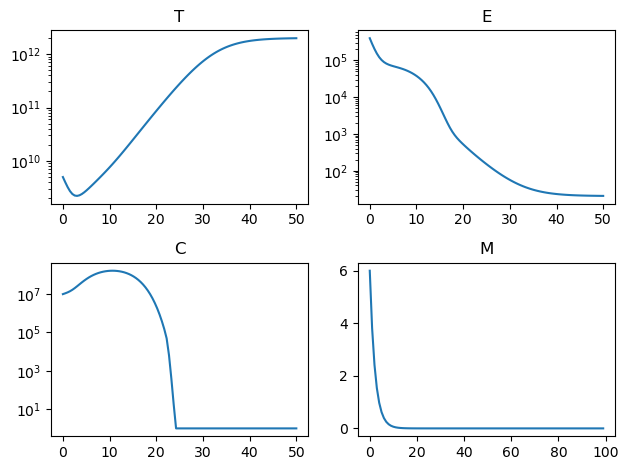

In [3]:
p1_params = {
    "a": 2.55e-1,
    "b_inv": 2e12,
    "dE": 2.03,
    "dC": 2.25,
    "g": 1.4e3,
    "jE": 1.1e-2,
    "jC": 2.42e-1,
    "K": 1.65e9,
    "k": 2.019e5,
    "l": 1.395,
    "mE": 7e-3,
    "mC": 2.93e-1,
    "qE": 3.42e-11,
    "qC": 3.0e-11,
    "s": 3.05e-1,
    "KT": 7e-1,
    "KE": 6e-1,
    "KC": 6e-1,
    "gamma": 9e-1,
}

p1_init_vals = {
    "T": 5e9,
    "E": 4e5,
    "C": 1e7,
    "M": 6,
}

owens_bozic_obs_var_names = owens_bozic_model.obs_var_names
owens_bozic_param_names = owens_bozic_model.param_names

p1_gt = owens_bozic_model.get_ground_truth(p1_params, p1_init_vals, 0, 50)
t = np.linspace(0, 50, 100)
fig, axs = plt.subplots(2, 2)
axs = axs.flatten()
for obs_var, ax in zip(owens_bozic_obs_var_names, axs):
    if obs_var == "M":
        ax.plot(p1_gt(t)[obs_var])
    else:
        ax.semilogy(t, np.maximum(p1_gt(t)[obs_var], 1))
    ax.set_title(obs_var)
plt.tight_layout()
plt.show()

## synthetic data

In [4]:
param_dists: dict[str, UnivarDist] = {
    "a": TruncLognorm(median=0.2, mlx_omega=0.5, upper_bound=0.6),
    "b_inv": TruncLognorm(median=1.37e11, mlx_omega=1.14, upper_bound=1e13),
    "dE": TruncLognorm(median=2.22, mlx_omega=0.34),
    "dC": Constant(2.25),
    "g": Constant(1.03e4),
    "jE": Constant(1.56e-2),
    "jC": TruncLognorm(median=3.46e-1, mlx_omega=0.75),
    "K": Constant(5.21e8),
    "k": Constant(8.67e6),
    "l": TruncLognorm(median=1.418, mlx_omega=0.15),
    "mE": Constant(1.7e-2),
    "mC": Constant(0.293),
    "qE": TruncLognorm(median=1.28e-10, mlx_omega=1.35),
    "qC": TruncLognorm(median=2.14e-10, mlx_omega=2.6),
    "s": TruncLognorm(median=0.302, mlx_omega=0.17, upper_bound=1),
    "KT": Constant(7e-1),
    "KE": Constant(6e-1),
    "KC": Constant(6e-1),
    "gamma": Constant(9e-1),
}

obs_var_init_val_dists = {
    "T": TruncLognorm(median=1.58e9, mlx_omega=1.5),
    "E": Constant(4e5),
    "C": TruncLognorm(median=6.3e7, mlx_omega=2.0),
    "M": TruncLognorm(median=6.0, mlx_omega=0.2),
}

In [5]:
def dists_to_independent_samples(
    dist_dict: dict[str, UnivarDist], rng: Generator, n_samples: int
) -> list[dict[str, float]]:
    """
    Independently sample from each distribution in `dist_dict` `n_samples` times,
    returning a list of `n_samples` dicts from keys in `dist_dict` to sampled values
    """
    keys = dist_dict.keys()
    dists = [dist_dict[key] for key in keys]
    sampler = independent_sampler(dists)
    sampled_val_lists = [sampler(rng) for _ in range(n_samples)]
    return [
        {k: v for k, v in zip(keys, vals)} for vals in sampled_val_lists  # type: ignore
    ]

In [6]:
rng = np.random.default_rng(seed=11111)
n_patients = 8
start_day = 0
end_day = 100

# generate ground truths
param_val_dicts = dists_to_independent_samples(param_dists, rng, n_patients)
init_val_dicts = dists_to_independent_samples(obs_var_init_val_dists, rng, n_patients)
ground_truths = [
    owens_bozic_model.get_ground_truth(
        param_val_dict, init_val_dict, start_day, end_day
    )
    for param_val_dict, init_val_dict in zip(param_val_dicts, init_val_dicts)
]

# subsample trajectories
obs_times = np.linspace(start_day, end_day, 20)
scheds: dict[str, ArrayLike] = {
    obs_var: obs_times for obs_var in owens_bozic_obs_var_names
}
trajectories_all = [
    subsample_trajectories(ground_truth, scheds) for ground_truth in ground_truths
]

# add noise
noise_level = 0.3
error_models = {
    "T": proportional_normal_error_model(noise_level, 1.0),
    "E": proportional_normal_error_model(noise_level, 1e-2),
    "C": proportional_normal_error_model(noise_level, 1.0),
    "M": proportional_normal_error_model(noise_level, 1e-2),
}
noisy_trajectories_all = [
    add_noise(trajectories, error_models, rng) for trajectories in trajectories_all
]

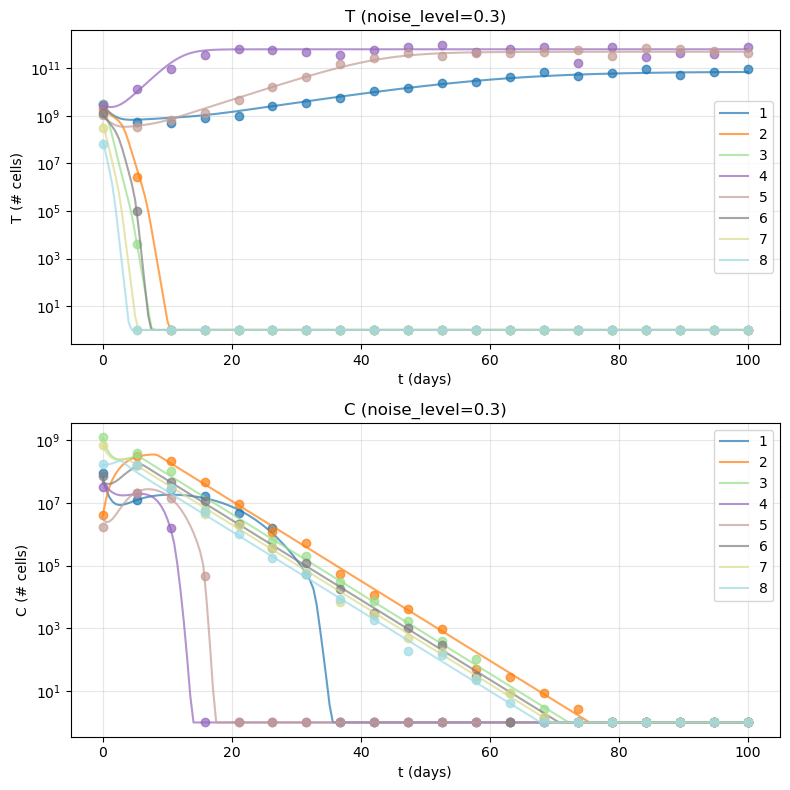

In [7]:
t = np.linspace(start_day, end_day, 200)

fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs = axs.flatten()

# Using tab20 colormap which has high contrast colors
colors = plt.cm.tab20(np.linspace(0, 1, n_patients))  # type: ignore

for i, (ground_truth, noisy_trajectories, color) in enumerate(
    zip(ground_truths, noisy_trajectories_all, colors)
):
    for obs_var, ax in zip(["T", "C"], axs):
        ax.semilogy(
            t,
            np.maximum(ground_truth(t)[obs_var], 1),
            label=f"{i+1}",
            color=color,
            alpha=0.7,
        )
        noisy_traj = noisy_trajectories[obs_var]
        ax.semilogy(
            noisy_traj["t"],
            noisy_traj["y"],
            "o",
            color=color,
            alpha=0.7,
        )
        ax.set_title(f"{obs_var} ({noise_level=})")
        ax.set_xlabel("t (days)")
        ax.set_ylabel(f"{obs_var} (# cells)")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

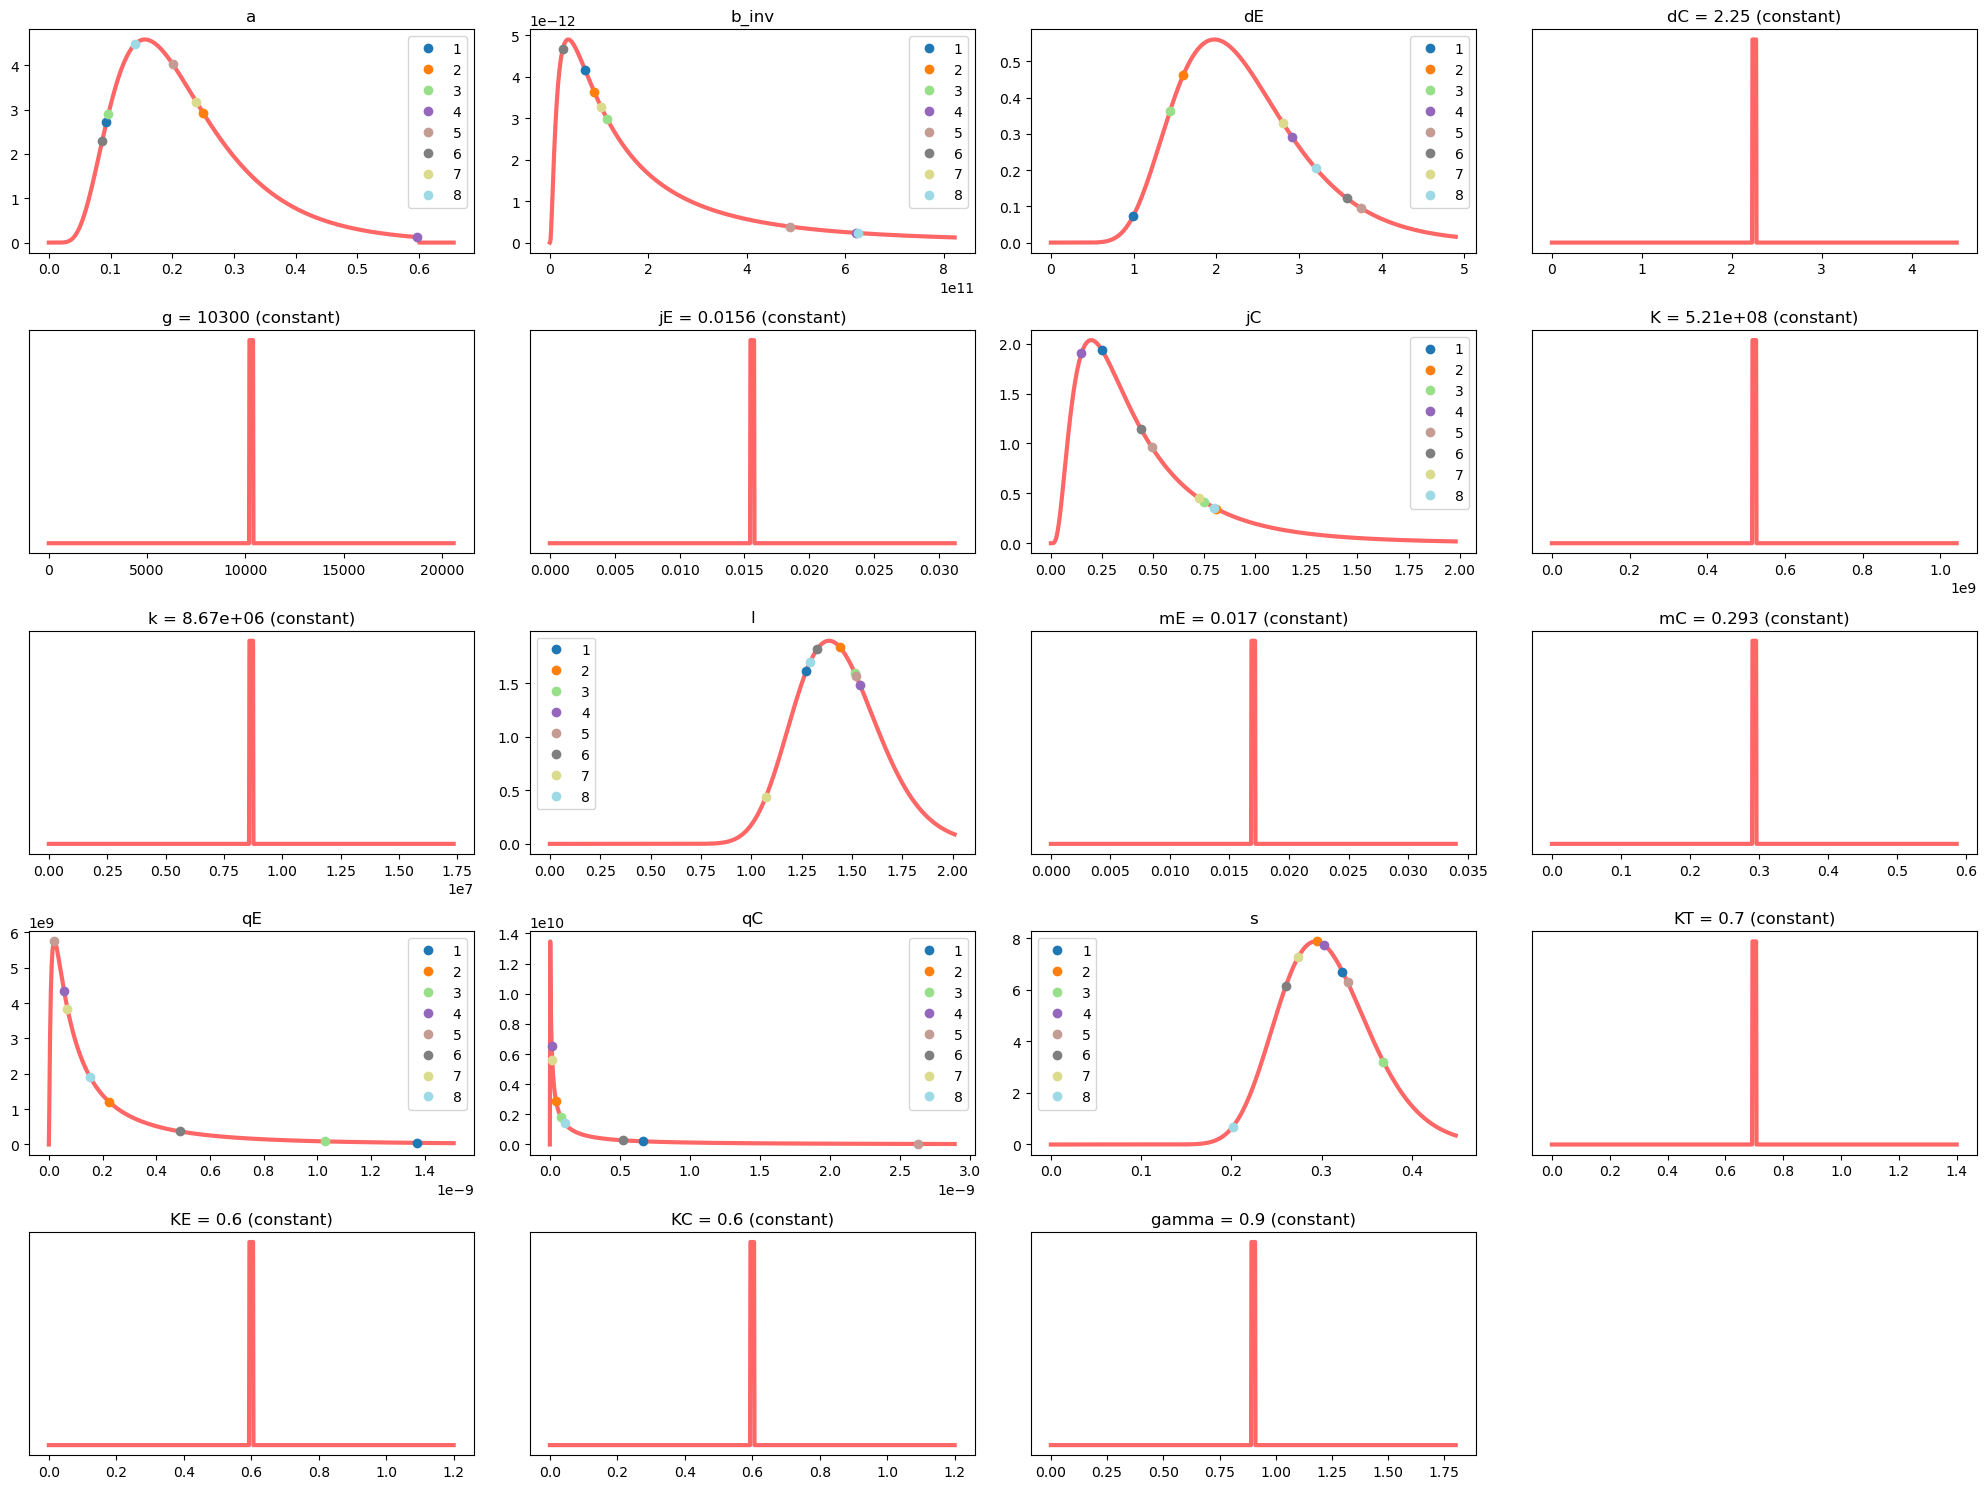

In [8]:
fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

for ax, (param_name, dist) in zip(axes, param_dists.items()):
    lower, upper = dist.plot_bounds()
    # avoid dist curve not covering all points
    upper = max(upper, 1.1 * max([d[param_name] for d in param_val_dicts]))
    x = np.linspace(lower, upper, 1000)
    ax.plot(x, dist.pdf(x), color="red", lw=3, alpha=0.6)
    if isinstance(dist, Constant):
        ax.set_yticks([])
        ax.set_title(f"{param_name} = {dist.sample(rng):g} (constant)")
    else:
        for i, (param_val_dict, color) in enumerate(zip(param_val_dicts, colors)):
            param_val = param_val_dict[param_name]
            upper = max(upper, param_val)
            ax.plot(param_val, dist.pdf(param_val), "o", color=color, label=f"{i+1}")
        ax.set_title(param_name)
        ax.legend()


for i in range(len(param_dists), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()